# Preliminary Data Analysis

## Source - University of Minnesota LakeBrowser
### Overview
Lake mapping and visualization project by the University of Minnesota to use landsat (1975-2015) and Sentinel2 (2017-today) remote sensing data to measure water clarity, clorophyll, and colored dissolved organic matter (CDOM) through the open water season (May-September).

https://lakes.rs.umn.edu/

https://water.rs.umn.edu/lakebrowser

https://github.com/GEMS-UMN/Exchange-Notebooks

## Package Installation & Import

In [39]:
# Install if needed:
%pip install requests pandas geopandas shapely rasterio pyproj tqdm matplotlib

import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import numpy as np
import rasterio
from shapely.geometry import shape, mapping, box
from requests import Session
from tqdm.notebook import tqdm

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## API Connection
I followed the directions provided in the GEMS-UMN/Exchange-Notebooks git hub repository to establish a connection to the API with a key and retrieve data.

https://github.com/GEMS-UMN/Exchange-Notebooks/blob/master/README.md



In [3]:
# Create a Session

from requests import Session
import sys
sys.path.append('..')
from api_key import key

s = Session()
s.headers.update({'apikey': key})

hydro_url = "https://exchange-1.gems.msi.umn.edu/hydro/v2"
landcover_url = "https://exchange-1.gems.msi.umn.edu/landcover/v2"

## Lake Search
Retrieving lake id, name, and acreage

In [ ]:
# Get all MN lakes in this API dataset

# Minnesota bbox
mn_bbox = "-97.5,43,-89.0,49.5"

# Convert bbox string to a GeoJSON polygon
minx, miny, maxx, maxy = map(float, mn_bbox.split(","))
mn_geom = mapping(box(minx, miny, maxx, maxy))

all_lakes = []
limit = 50
offset = 0

while True:
    params = {
        "limit": limit,
        "offset": offset
    }

    r = s.post(
        f"{hydro_url}/lake-mn/search",
        json=mn_geom,
        params=params
    )

    if r.status_code != 200:
        print("Status code:", r.status_code)
        print("Response text:", r.text)
        break

    batch = r.json()

    if len(batch) == 0:
        break

    all_lakes.extend(batch)
    print(f"Pulled {len(all_lakes)} lakes so far...")

    offset += limit

lakes_df = pd.DataFrame(all_lakes)

print(f"Total lakes pulled: {len(lakes_df)}")
lakes_df.head()

Pulled 50 lakes so far...
Pulled 100 lakes so far...
Pulled 150 lakes so far...
Pulled 200 lakes so far...
Pulled 250 lakes so far...
Pulled 300 lakes so far...
Pulled 350 lakes so far...
Pulled 400 lakes so far...
Pulled 450 lakes so far...
Pulled 500 lakes so far...
Pulled 550 lakes so far...
Pulled 600 lakes so far...
Pulled 650 lakes so far...
Pulled 700 lakes so far...
Pulled 750 lakes so far...
Pulled 800 lakes so far...
Pulled 850 lakes so far...
Pulled 900 lakes so far...
Pulled 950 lakes so far...
Pulled 1000 lakes so far...
Pulled 1050 lakes so far...
Pulled 1100 lakes so far...
Pulled 1150 lakes so far...
Pulled 1200 lakes so far...
Pulled 1250 lakes so far...
Pulled 1300 lakes so far...
Pulled 1350 lakes so far...
Pulled 1400 lakes so far...
Pulled 1450 lakes so far...
Pulled 1500 lakes so far...
Pulled 1550 lakes so far...
Pulled 1600 lakes so far...
Pulled 1650 lakes so far...
Pulled 1700 lakes so far...
Pulled 1750 lakes so far...
Pulled 1800 lakes so far...
Pulled 1850 

,id,name,acres
0,52001600,Unnamed,18.621271
1,41014600,Unnamed,11.292937
2,51009700,Unnamed,19.030874
3,53004700,Unnamed,29.292933
4,22002200,South Walnut,1149.852044


## Cleaning Lake Search Results

Run some preliminary cleaning steps to make sure the lake search results are in the right format, don't have duplicate rows, and are only those bodies of water considered "lakes" (>10 acres according to the MN DNR).

In [26]:
# make sure acres column is numberic
lakes_df["acres"] = pd.to_numeric(lakes_df["acres"], errors="coerce")

# drop any duplicates based on the id column
lakes_df = lakes_df.drop_duplicates(subset='id')

# strip and lower name column
lakes_df["name"] = lakes_df["name"].str.lower().str.strip()

# filtering results to only include lakes >10 acres
lakes_df = lakes_df[lakes_df["acres"] > 10]

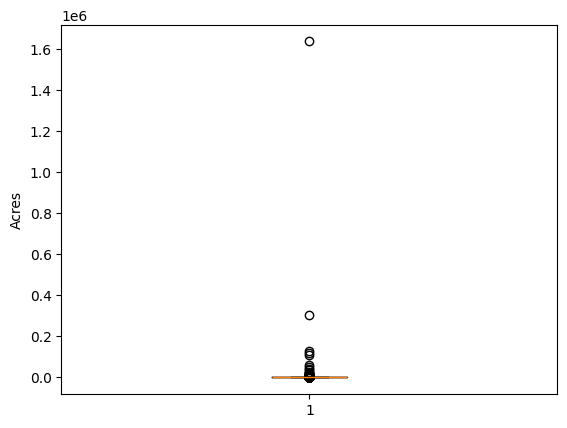

In [27]:
# simple boxplot of the lake acres to see general distribution
plt.boxplot(lakes_df['acres'])
plt.ylabel('Acres')
plt.show()

There is one lake that is a huge outlier and is skewing the acreage. I suspect this is Lake Superior, which I'd want to exclude from this analysis due to it's unique size and features that make it more similar to a freshwater sea than a typical midwestern lake.

In [28]:
# View the lakes with the 10 largest acreage
lakes_df.sort_values("acres", ascending=False).head(10)

,id,name,acres
15659,16000100,superior,1.634599e+06
20990,39000200,lake of the woods,3.057742e+05
13092,48000200,mille lacs,1.286490e+05
18224,04003501,upper red,1.196409e+05
19020,11020300,leech,1.107837e+05
18307,11014700,winnibigoshish,6.048468e+04
21223,69069400,rainy,5.214794e+04
13736,69037800,east vermilion,3.981891e+04
21183,45000200,mud,3.838879e+04
1436,25000100,pepin,2.533029e+04


In [34]:
# Remove Lake Superior
lakes_df = lakes_df[lakes_df["id"] != "16000100"]

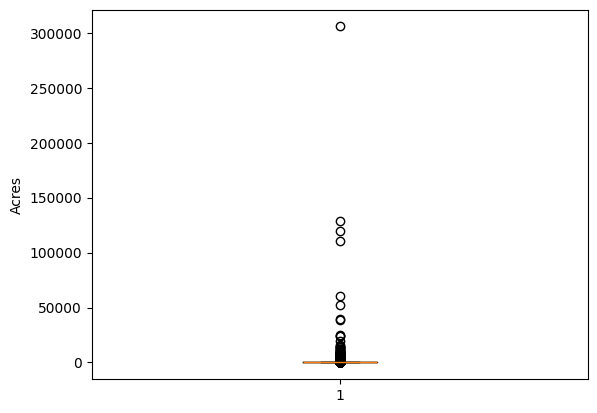

In [35]:
# re-plot boxplot to see distribution without Superior
plt.boxplot(lakes_df['acres'])
plt.ylabel('Acres')
plt.show()

## Lake Geometries

In [38]:
# subset of the data to test how long the geometries pull will take
test_lakes_df = lakes_df.sample(
    n=min(100, len(lakes_df)),
    random_state=42
).copy()

print(f"Test subset size: {len(test_lakes_df)}")

Test subset size: 100


In [40]:
lake_records = []

start_time = time.time()

for _, lake in tqdm(test_lakes_df.iterrows(), total=len(test_lakes_df)):
    lake_id = lake["id"]
    
    r = s.get(f"{hydro_url}/lake-mn/{lake_id}/geometry")
    
    if r.status_code in [400, 404]:
        continue
    
    r.raise_for_status()
    geom_json = r.json()["geometry"]
    
    lake_records.append({
        "lake_id": lake_id,
        "lake_name": lake.get("name"),
        "acres": lake.get("acres"),
        "geometry": shape(geom_json)
    })

end_time = time.time()

lakes_gdf = gpd.GeoDataFrame(lake_records, crs="EPSG:4326")

elapsed_minutes = (end_time - start_time) / 60

print(f"Lake geometries retrieved: {len(lakes_gdf)}")
print(f"Elapsed time: {elapsed_minutes:.2f} minutes")

lakes_gdf.head()

  0%|          | 0/100 [00:00<?, ?it/s]

Lake geometries retrieved: 100
Elapsed time: 0.11 minutes


,lake_id,lake_name,acres,geometry
0,38060200,discovery,33.995896,"MULTIPOLYGON (((-91.48461 47.96888, -91.48438 ..."
1,73044000,unnamed,18.916005,"MULTIPOLYGON (((-94.7633 45.69744, -94.76368 4..."
2,56155900,unnamed,29.761968,"MULTIPOLYGON (((-95.90789 46.47658, -95.90744 ..."
3,69051400,unnamed,12.952045,"MULTIPOLYGON (((-92.35231 47.00199, -92.35241 ..."
4,38080900,chippewa,83.710750,"MULTIPOLYGON (((-91.77895 48.15979, -91.77901 ..."


In [41]:
seconds_per_lake = (end_time - start_time) / len(test_lakes_df)

estimated_seconds_all = seconds_per_lake * len(lakes_df)
estimated_minutes_all = estimated_seconds_all / 60
estimated_hours_all = estimated_minutes_all / 60

print(f"Seconds per lake: {seconds_per_lake:.3f}")
print(f"Estimated time for all lakes >10 acres: {estimated_minutes_all:.1f} minutes")
print(f"Estimated time for all lakes >10 acres: {estimated_hours_all:.2f} hours")

Seconds per lake: 0.067
Estimated time for all lakes >10 acres: 20.9 minutes
Estimated time for all lakes >10 acres: 0.35 hours
